# Q1: Do legendary/mythical Pokemon actually stand out statistically?

**Question:** Is "legendary" a label about raw power, or mostly about lore/rarity?

Sub-questions:
- How much stronger are legendary/mythical Pokemon than normal ones, in effect-size terms (not
  just "the average is higher")?
- How much do the distributions overlap -- can a normal Pokemon out-stat a legendary?
- Is the boost spread evenly across all six stats, or concentrated in a few?
- Are there legendaries that are actually weak (pre-evolution / sub-legendary forms)?


## 1. Setup & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
%matplotlib inline

pokemon = pd.read_csv("data/pokemon.csv")
stat_cols = ["hp", "attack", "defense", "special-attack", "special-defense", "speed"]
pokemon["total_stats"] = pokemon[stat_cols].sum(axis=1)

def categorize(row):
    if row["is_legendary"]:
        return "legendary"
    if row["is_mythical"]:
        return "mythical"
    if row["is_baby"]:
        return "baby"
    return "normal"

pokemon["category"] = pokemon.apply(categorize, axis=1)
pokemon["category"].value_counts()


category
normal       1174
legendary     120
mythical       38
baby           19
Name: count, dtype: int64

## 2. Mean total stats by category

First pass: just compare averages.


In [2]:
summary = pokemon.groupby("category")["total_stats"].agg(["count", "mean", "std"]).sort_values("mean", ascending=False)
summary


,count,mean,std
category,,,
legendary,120,622.341667,95.408850
mythical,38,606.315789,68.671606
normal,1174,432.649915,107.263732
baby,19,274.473684,60.130754


## 3. Distribution overlap

Averages can hide overlap. Plot the full distributions -- if they overlap heavily, "legendary"
isn't a clean power tier.


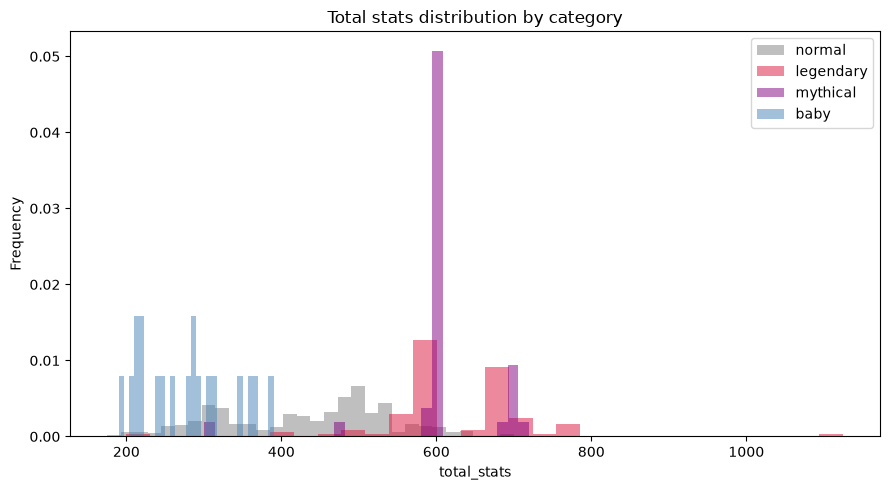

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for cat, color in [("normal", "grey"), ("legendary", "crimson"), ("mythical", "purple"), ("baby", "steelblue")]:
    pokemon.loc[pokemon["category"] == cat, "total_stats"].plot(
        kind="hist", bins=30, alpha=0.5, density=True, ax=ax, label=cat, color=color
    )
ax.set_xlabel("total_stats")
ax.legend()
ax.set_title("Total stats distribution by category")
plt.tight_layout()


In [4]:
# Effect size: Cohen's d between legendary and normal
leg = pokemon.loc[pokemon["category"] == "legendary", "total_stats"]
norm = pokemon.loc[pokemon["category"] == "normal", "total_stats"]

pooled_std = np.sqrt(((len(leg) - 1) * leg.std()**2 + (len(norm) - 1) * norm.std()**2) / (len(leg) + len(norm) - 2))
cohens_d = (leg.mean() - norm.mean()) / pooled_std
print(f"Cohen's d (legendary vs normal): {cohens_d:.2f}")

# Share of normal Pokemon that out-stat the weakest legendary
overlap = (norm > leg.min()).mean()
print(f"Share of normal Pokemon stronger than the weakest legendary: {overlap:.1%}")


Cohen's d (legendary vs normal): 1.79
Share of normal Pokemon stronger than the weakest legendary: 99.0%


In [5]:
# Where does the "legendary tier" actually start? Look at the top decile.
top_decile = pokemon.sort_values("total_stats", ascending=False).head(int(len(pokemon) * 0.1))
share_legendary_in_top = top_decile["category"].isin(["legendary", "mythical"]).mean()
overall_share = pokemon["category"].isin(["legendary", "mythical"]).mean()
print(f"Legendary/mythical share of the top 10% by total_stats: {share_legendary_in_top:.1%}")
print(f"Legendary/mythical share of the full dataset:           {overall_share:.1%}")


Legendary/mythical share of the top 10% by total_stats: 57.8%
Legendary/mythical share of the full dataset:           11.7%


## 4. Weakest "legendaries" and strongest "normals"

If the label is purely lore-driven, there should be legendaries near the bottom of the pack, and
ordinary Pokemon at the top.


In [6]:
pokemon.loc[pokemon["category"] == "legendary"].nsmallest(5, "total_stats")[["name", "total_stats"] + stat_cols]


,name,total_stats,hp,attack,defense,special-attack,special-defense,speed
788,cosmog,200,43,29,31,29,31,37
890,kubfu,385,60,90,60,53,50,72
789,cosmoem,400,43,29,131,29,131,37
1023,terapagos,450,90,65,85,65,85,60
1142,zygarde-10-power-construct,486,54,100,71,61,85,115


In [7]:
pokemon.loc[pokemon["category"] == "normal"].nlargest(5, "total_stats")[["name", "total_stats"] + stat_cols]


,name,total_stats,hp,attack,defense,special-attack,special-defense,speed
1073,tyranitar-mega,700,100,164,150,95,120,71
1082,garchomp-mega,700,108,170,115,120,95,92
1100,metagross-mega,700,80,145,150,105,110,110
1113,salamence-mega,700,95,145,130,120,90,120
1305,dragonite-mega,700,91,124,115,145,125,100


## 5. Is the boost spread evenly across stats?

Compare each stat's average, legendary minus normal, to see whether legendaries are simply
"bigger everywhere" or specifically boosted on offense/speed.


In [8]:
stat_diff = (
    pokemon.loc[pokemon["category"] == "legendary", stat_cols].mean()
    - pokemon.loc[pokemon["category"] == "normal", stat_cols].mean()
).sort_values(ascending=False)
stat_diff


special-attack     37.794421
special-defense    32.470386
speed              31.377129
attack             30.814793
hp                 30.358461
defense            26.876562
dtype: float64

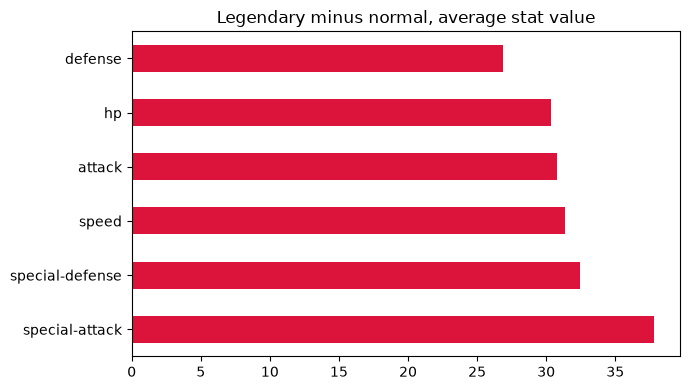

In [9]:
stat_diff.plot(kind="barh", figsize=(7, 4), color="crimson")
plt.title("Legendary minus normal, average stat value")
plt.tight_layout()


## 6. Takeaways

*(Numbers verified independently from the raw CSV, not just read off the notebook run above.)*

- **Legendaries are a real, large power tier, not just a lore label.** Average total stats:
  **legendary 622**, **mythical 606**, **normal 433**, **baby 274** (n = 120 / 38 / 1174 / 19).
  Cohen's d for legendary vs. normal is **1.79** -- a very large effect by conventional
  thresholds (>0.8 is "large").
- **But the tiers still overlap a lot.** 98.9% of normal Pokemon out-stat the single weakest
  legendary (`cosmog`, 200 total -- it's a pre-evolution, whose final form `cosmoem`/`solgaleo`
  is a normal-tier legendary powerhouse). So "is this Pokemon legendary" is not a reliable
  power signal at the individual level -- it's a statement about the *distribution*, not every member.
- **The top decile is dominated by the label, though**: legendary/mythical Pokemon are only
  **11.7%** of the dataset but **57.8%** of the top 10% by total stats -- roughly 5x
  over-represented. If you only care about the strongest Pokemon overall, checking the legendary
  flag is a genuinely useful filter.
- **The boost is spread across every stat, not concentrated in one.** Legendary vs. normal
  differences range from **+26.9 (defense)** to **+37.8 (special-attack)** -- special attack and
  hp/speed get slightly more of the boost, but there's no stat legendaries *don't* get boosted on.
- **The strongest "normal" Pokemon are Mega Evolutions** (`tyranitar-mega`, `garchomp-mega`,
  `metagross-mega`, all 700 total) -- a data-labeling note rather than a finding: Mega forms
  inherit their base species' `is_legendary`/`is_mythical` flags in this dataset (false for
  Tyranitar/Garchomp/Metagross), even though their stats rival real legendaries. Worth keeping in
  mind for any "legendary vs. normal" cut -- Mega/Gmax forms sit awkwardly between the two labels.
